## Plot trace plots (K,TL,particle spectrum)

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import ast
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import tarfile
import io


In [2]:
plt.rcParams.update({
     "text.usetex": True,
     "font.family": "serif",
     "font.serif": ["Palatino"],
 })
plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 16,
    "axes.titlesize": 20,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 12,
    "figure.dpi": 140,
    "axes.linewidth": 1.4,
})

In [3]:
walks = np.arange(501,551)
#select subset
walks = [503,518,524,541]
tar_file = "../real_run/all_walks.tar.gz"

In [4]:
acc_proto = {}
with tarfile.open(tar_file, 'r:gz') as tar:
    for ind,member in enumerate(tar.getmembers()):
        print("\n",member.name)
        dictfile = tar.extractfile(member)
        try:
            content = dictfile.read().decode('utf-8')
            di = eval(content) 
        except Exception as e:
            print(f"Skipping {member.name} due to error: {e}")
            continue
        
        #plotting only for select walks
        walkerid = int(member.name.split('t')[1].split('.')[0])
        if walkerid not in walks: continue
        
        n_acc = 0
        acc_proto[ind+1] = {'dictlist':[],'n_acc':0,'acc_rate':0.0}
        last_step = di[-1]['step']

        for i, d in enumerate(di):
            if d == {}:continue
            acc = d['Accepted']
            if acc == 0:
                n_acc +=1
                K = d['K']
                TL = d['TL']
                acc_d = {'step': d['step'], 'K':d['K'], 'TL':d['TL']}
                acc_proto[ind+1]['dictlist'].append(acc_d)

        print("Number of accepted protomodels: ", n_acc)
        print("Acceptance rate: ", n_acc/last_step)
        acc_proto[ind+1]['n_acc'] = n_acc
        acc_proto[ind+1]['acc_rate'] = n_acc/last_step
    


 all_dict501.dict

 all_dict502.dict

 all_dict503.dict
Number of accepted protomodels:  12088
Acceptance rate:  0.6044302215110755

 all_dict504.dict

 all_dict505.dict

 all_dict506.dict

 all_dict507.dict

 all_dict508.dict

 all_dict509.dict

 all_dict510.dict

 all_dict511.dict

 all_dict512.dict

 all_dict513.dict

 all_dict514.dict

 all_dict515.dict

 all_dict516.dict

 all_dict517.dict

 all_dict518.dict
Number of accepted protomodels:  12830
Acceptance rate:  0.6415641564156416

 all_dict519.dict

 all_dict520.dict

 all_dict521.dict

 all_dict522.dict

 all_dict523.dict

 all_dict524.dict
Number of accepted protomodels:  12363
Acceptance rate:  0.6181809090454523

 all_dict525.dict

 all_dict526.dict

 all_dict527.dict

 all_dict528.dict

 all_dict529.dict

 all_dict530.dict

 all_dict531.dict

 all_dict532.dict

 all_dict533.dict

 all_dict534.dict

 all_dict535.dict

 all_dict536.dict

 all_dict537.dict

 all_dict538.dict

 all_dict539.dict

 all_dict540.dict

 all_dict54

In [5]:
#plot trace of K, TL
def get_ktl_list(dlist):
    K_list,TL_list,step_list = [],[],[]
    for i, d in enumerate(dlist):
        step_list.append(d['step'])
        K_list.append(d['K'])
        TL_list.append(d['TL'])
    
    return K_list, TL_list, step_list

def plot_trace_K(K_list, TL_list, step_list, change=False):

    #get maxK and step 
    max_index = int(np.argmax(K_list))
    max_step  = step_list[max_index]
    max_K     = K_list[max_index]
    
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.07, row_heights=[0.45, 0.55])

    # First subplot (K)
    fig.add_trace(go.Scatter(x=step_list, y=K_list, mode='lines', name='K'), row=1, col=1)

    # Add marker at max(K)
    if change:
        #change text position
        fig.add_trace(go.Scatter(x=[max_step],y=[max_K],mode="markers+text",marker=dict(size=7, color="black"),
                text=[f"<i>K<i> = {max_K:.2f}"],textposition="middle left", textfont=dict(size=16, family="Computer Modern"),
                showlegend=False),row=1, col=1)
    else:
        fig.add_trace(go.Scatter(x=[max_step],y=[max_K],mode="markers+text",marker=dict(size=7, color="black"),
                text=[f"<i>K<i> = {max_K:.2f}"],textposition="middle right", textfont=dict(size=16, family="Computer Modern"),
                showlegend=False),row=1, col=1)
    
    # Second subplot (TL)
    fig.add_trace(go.Scatter(x=step_list, y=TL_list, mode='lines', name='TL', line=dict(color='red')), row=2, col=1)
    if change:
        fig.add_trace(go.Scatter(x=[max_step],y=[TL_list[max_index]],mode="markers+text",marker=dict(size=7, color="black"),
                text=[f"<i>TL<i> = {TL_list[max_index]:.2f}"],textposition="middle left",textfont=dict(size=16, family="Computer Modern"),
                showlegend=False),row=2, col=1)
    else:
        fig.add_trace(go.Scatter(x=[max_step],y=[TL_list[max_index]],mode="markers+text",marker=dict(size=7, color="black"),
                text=[f"<i>TL<i> = {TL_list[max_index]:.2f}"],textposition="middle right",textfont=dict(size=16, family="Computer Modern"),
                showlegend=False),row=2, col=1)
    

    # Update layout
    fig.update_layout(height=500, width=800, showlegend=False, font=dict(family="Computer Modern",size=20))
    #title=dict(text=r"$K$ and $TL$ as a Function of Step",x=0.5,xanchor="center",yanchor="top"))
    fig.update_xaxes(title_text="Step", showgrid=True, ticks="outside", row=2, col=1, )
    fig.update_yaxes(title_text=r"<i>K<i>",showgrid=True, ticks="outside", row=1, col=1)
    fig.update_yaxes(title_text=r"<i>TL<i>", showgrid=True, ticks="outside", row=2, col=1)

    

    import plotly.io as pio
    pio.renderers.default = "vscode" 
    pio.show(fig)
    


In [6]:
#plot density (if required)
def plot_density(klist, tllist):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
    axes[0].hist(klist,edgecolor='black')
    axes[0].set_title('K distribution')

    axes[1].hist(tllist,edgecolor='black')
    axes[1].set_title('TL distribution')

    plt.tight_layout()
    plt.show()

def plot_overall_density(overall_k, overall_tl):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
    full_k_list, full_tl_list = [],[] 
    for ind, k_list in overall_k.items():
        full_k_list += k_list             #append(k_list)
        full_tl_list +=overall_tl[ind]    #.append(overall_tl[ind])
        axes[0,0].hist(k_list,fill=True, edgecolor='black', label=ind, alpha=0.5)
        axes[0,1].hist(overall_tl[ind],fill=True, edgecolor='black', label=ind, alpha=0.5)    #, alpha=0.5

    axes[0,0].set_title('K distribution')
    axes[0,1].set_title('TL distribution')
    #axes[0,0].legend()
    axes[0,1].legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    #full_k_list = np.array(full_k_list)
    #full_tl_list = np.array(full_tl_list)
    axes[1,0].hist(full_k_list,fill=True, edgecolor='black')
    axes[1,0].set_title('Overall K distribution')
    #axes[0].set_label(f'{ind}')

    axes[1,1].hist(full_tl_list,fill=True, edgecolor='black')
    axes[1,1].set_title('Overall TL distribution')
    plt.tight_layout()
    #axes[1].set_label(f'{ind}')

In [7]:
#get the trace plots
avg_acc_rate = 0.0
for ind,proto in acc_proto.items():
    print("Walker ",ind, " % accepted", proto['acc_rate']*100)
    K_list,TL_list,step_list = get_ktl_list(proto['dictlist'])
    print("Steps ", step_list[-1])
    step_list[-1] = 20000
    if step_list[-1] > 10000:
        if ind == 41: plot_trace_K(K_list, TL_list, step_list,change=True)
        else:plot_trace_K(K_list, TL_list, step_list)
        #plot_density(K_list, TL_list)
        avg_acc_rate += proto['acc_rate']

avg_acc_rate = avg_acc_rate/len(acc_proto)
print(avg_acc_rate)

Walker  3  % accepted 60.44302215110755
Steps  19999


Walker  18  % accepted 64.15641564156415
Steps  19998


Walker  24  % accepted 61.81809090454523
Steps  19999


Walker  41  % accepted 63.294494174126115
Steps  19997


0.6242800571783577


### Particle spectrum

In [8]:
#create mapping from each particle configuration

model_index = {'1:0': [1000022], '2:0':[1000022, 1000023], '2:1': [1000022, 1000024], '3:0':[1000022, 1000023, 1000025], '3:1': [1000022, 1000023, 1000024], '3:2': [1000022, 1000024, 1000037], '4:0':[1000022, 1000023, 1000024, 1000025], '4:1':[1000022, 1000023, 1000024, 1000037], '5:0':[1000022, 1000023, 1000024, 1000025, 1000037] }

model_label = {'$X_{Z}^{1}$': [1000022],'$X_{Z}^{1},X_{Z}^{2}$': [1000022, 1000023], '$X_{Z}^{1},X_{W}^{1}$': [1000022, 1000024], '$X_{Z}^{1},X_{Z}^{2},X_{W}^{1}$': [1000022, 1000023,1000024], '$X_{Z}^{1},X_{Z}^{2},X_{Z}^{3}$': [1000022, 1000023,1000025], '$X_{Z}^{1},X_{W}^{1},X_{W}^{2}$': [1000022,1000024,1000037], '$X_{Z}^{1},X_{Z}^{2},X_{Z}^{3},X_{W}^{1}$': [1000022,1000023,1000024,1000025], '$X_{Z}^{1},X_{Z}^{2},X_{W}^{1},X_{W}^{2}$': [1000022,1000023,1000024,1000037], '$X_{Z}^{1},X_{Z}^{2},X_{Z}^{3},X_{W}^{1},X_{W}^{2}$': [1000022,1000023,1000024,1000025,1000037]}

model_order = {'1': [1000022], '2':[1000022, 1000023], '3': [1000022, 1000024], '4':[1000022, 1000023, 1000025], '5': [1000022, 1000023, 1000024], '6': [1000022, 1000024, 1000037], '7':[1000022, 1000023, 1000024, 1000025], '8':[1000022, 1000023, 1000024, 1000037], '9':[1000022, 1000023, 1000024, 1000025, 1000037] }

model_list = {}


for par_label, par_cont in model_label.items():
    md = {mi:par_label for mi,par in model_order.items() if par==par_cont}
    model_list.update(md)

model_list

{'1': '$X_{Z}^{1}$',
 '2': '$X_{Z}^{1},X_{Z}^{2}$',
 '3': '$X_{Z}^{1},X_{W}^{1}$',
 '5': '$X_{Z}^{1},X_{Z}^{2},X_{W}^{1}$',
 '4': '$X_{Z}^{1},X_{Z}^{2},X_{Z}^{3}$',
 '6': '$X_{Z}^{1},X_{W}^{1},X_{W}^{2}$',
 '7': '$X_{Z}^{1},X_{Z}^{2},X_{Z}^{3},X_{W}^{1}$',
 '8': '$X_{Z}^{1},X_{Z}^{2},X_{W}^{1},X_{W}^{2}$',
 '9': '$X_{Z}^{1},X_{Z}^{2},X_{Z}^{3},X_{W}^{1},X_{W}^{2}$'}

In [9]:
def plot_posterior_prob(model_prob, type):
    step_list = {mi:[] for mi in model_list.keys()}
    prob_list = {mi:[] for mi in model_list.keys()}
    fig = plt.figure(figsize=(11, 6),constrained_layout=True)
    model_color = {'0:0': 'black', '1:0': 'lightblue', '2:0':'blue', '2:1':'orange', '3:0':'darkblue', '3:1': 'red', '3:2': 'crimson', '4:0': 'green', '4:1': 'olive', '5:0':'pink' }

    #print(step_list)
    for mi, mprob in model_prob.items():
        #print(mi,mprob)
        for probm in mprob:
            step_list[mi].append(probm['step'])
            prob_list[mi].append(probm['prob'])

        #for mi in model_list:
        plt.plot(step_list[mi][1000:], prob_list[mi][1000:], label=model_list[mi], color=model_color[mi],linewidth=2)

    plt.rcParams['font.family'] = 'Times New Roman'
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.xlabel('Step', fontsize=18, fontfamily='Times New Roman')
    plt.ylabel('Integrated Probability', fontsize=18, fontfamily='Times New Roman')
    plt.title(f'Proto-model Probability Evolution', fontsize=20, fontfamily='Times New Roman')
    plt.tick_params(axis='both', which='major', labelsize=16)
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=16, title='Proto-model Particle Content', title_fontsize=18)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    #plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    #plt.savefig('/Users/sahananarasimha/Desktop/model_prob.png', dpi=200)
    plt.show()

In [16]:
for ind, mprob in all_model_posterior.items():
    #if ind==11:
    # Create a figure with two subplots
    print(ind)
    #print(model_posterior)
    plot_posterior_prob(mprob, "accepted")

3


AttributeError: 'list' object has no attribute 'items'

<Figure size 1540x840 with 0 Axes>

### Record model counts and probability

In [19]:
def occ_frac(model_count, step):
    
    occ_frac = {mi:0 for mi in model_list.keys()}
    for model_order, count in model_count.items():
        occ_frac[model_order] = count/step
    
    return occ_frac

def cumul_occ_frac(model_count, step):
    
    cum_frac = {mi:0 for mi in model_list.keys()}
    for model_order in model_count.keys():
        total_count = [count for mi,count in model_count.items() if mi <= model_order]
        cum_frac[model_order] = sum(total_count)/step
    
    return cum_frac


cumul_frac = {}
model_count = {}
model_posterior = {}
with tarfile.open(tar_file, 'r:gz') as tar:
    # List files inside the archive
    for ind,member in enumerate(tar.getmembers()):
        walkerid = int(member.name.split('t')[1].split('.')[0])
        if walkerid not in walks: continue
        if walkerid != 503:continue #absolute best-performing proto-model
        print("\n",member.name)
        dictfile = tar.extractfile(member)
        # Read and evaluate content
        try:
            content = dictfile.read().decode('utf-8')
            di = eval(content)  
        except Exception as e:
            print(f"Skipping {member.name} due to error: {e}")
            continue
        
        cumul_frac[ind+1] = []
        model_count[ind+1] = {mi:0 for mi in list(model_list.keys())}
        model_step = di[-1]['step']
        model_posterior[ind+1] = {mi:0 for mi in list(model_list.keys())} #for histogram of model counts

        for i, d in enumerate(di):
            if d == {}:continue
            elif d['Accepted'] == 0:
                masses = d['masses']
                par_type = list(masses.keys())
                #print(par_type)
                if par_type not in model_label.values():
                    print(par_type, d['step'])
                else:
                    mindex = [mi for mi, pt in model_order.items() if pt==par_type]
                    #if mindex[0] == '1': print(d)
                    if i==0: model_count[ind+1][mindex[0]] = 1
                    else: 
                        #model count = total number of steps between the current accepted protomodel and the next
                        model_count[ind+1][mindex[0]] += (d['step'] - di[i-1]['step']) #total number of steps
                        if d['step'] > 3500: 
                            #consider 3500 steps as burn in for histogram of model counts
                            model_posterior[ind+1][mindex[0]] += (d['step'] - di[i-1]['step']) #total number of steps
            else:continue
            cumul_frac[ind+1].append({'step': d['step'], 'occ_frac': occ_frac(model_count[ind+1], d['step']), 'cumul_frac': cumul_occ_frac(model_count[ind+1], d['step'])})
        
        



 all_dict503.dict


3


<Figure size 1120x840 with 0 Axes>

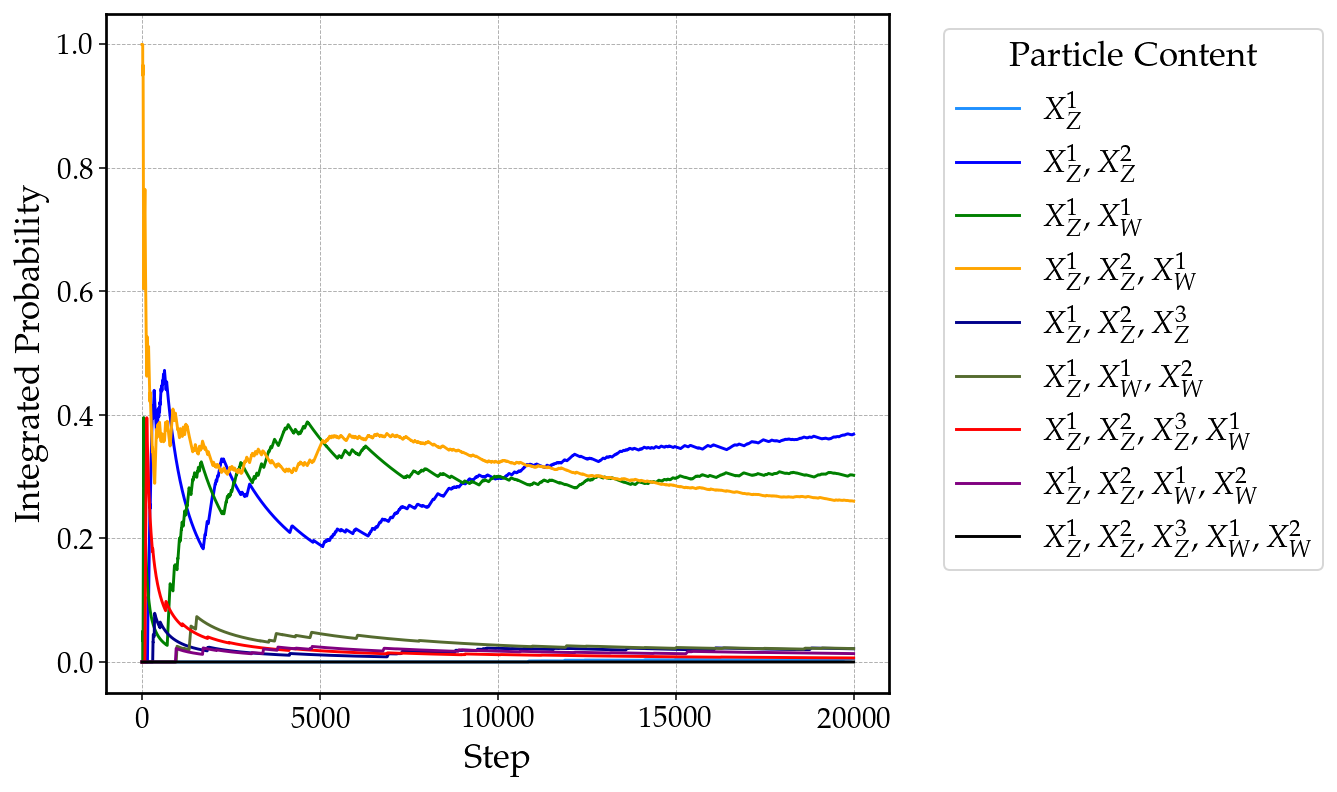

In [20]:
def plot_cumul_prob(model_posterior):
    step_list = {mi:[] for mi in model_order.keys()}
    occ_list = {mi:[] for mi in model_order.keys()}
    frac_list = {mi:[] for mi in model_order.keys()}
    fig = plt.figure(figsize=(8, 6),constrained_layout=True)
    model_color = {'1': 'dodgerblue', '2': 'blue', '3':'green', '4':'darkblue', '5':'orange', '6': 'darkolivegreen', '7': 'red', '8': 'purple', '9': 'black', '10':'pink' }

    fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharey=True, constrained_layout=True)
    
    for mi in model_list.keys():
        if mi == 1: continue
        for mdict in model_posterior:
            step_list[mi].append(mdict['step'])
            occ_list[mi].append(mdict['occ_frac'][mi])
            frac_list[mi].append(mdict['cumul_frac'][mi])
        ax.plot(step_list[mi], occ_list[mi], label=model_list[mi], color=model_color[mi],linewidth=1.5)


    ax.set_xlabel('Step', fontsize=18)
    ax.set_ylabel('Integrated Probability', fontsize=18)

    ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=16, title='Particle Content', title_fontsize=18)
    plt.tick_params(axis='both', which='major', labelsize=15)
    
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

for ind, cf in cumul_frac.items():
    print(ind)
    plot_cumul_prob(cf)

## plot histogram of model counts

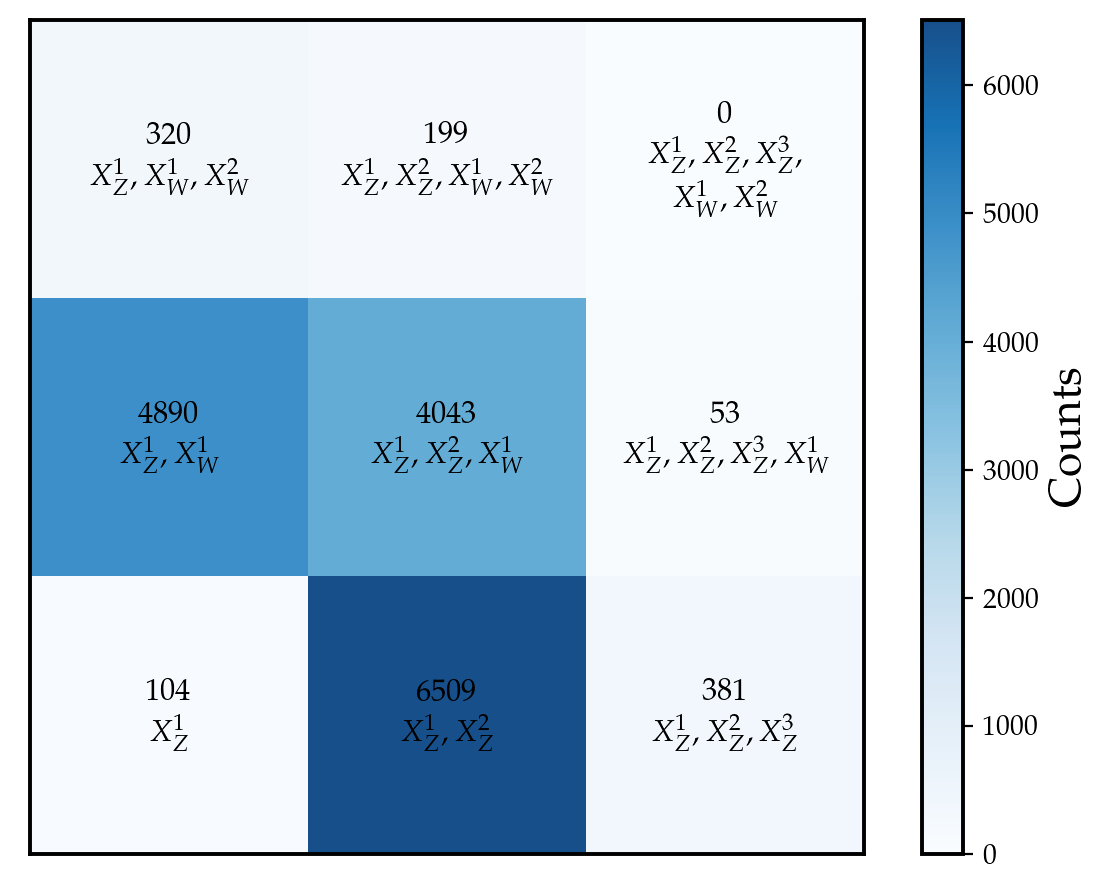

In [21]:
model = model_posterior[3]
# Data matrix
data = np.array([
    [model['1'], model['2'], model['4']],
    [model['3'], model['5'], model['7']],
    [model['6'], model['8'], model['9']]
])

# Axis labels (Y and X)
y_labels = [
    r"$X_Z^1$", 
    r"$X_Z^1, X_Z^2$", 
    r"$X_Z^1, X_Z^2, X_Z^3$"
]

x_labels = [
    r"$X_W^1, X_W^2$", 
    r"$X_Z^1, X_Z^2, X_W^1, X_W^2$", 
    r"$X_Z^1, X_Z^2, X_Z^3, X_W^1, X_W^2$"
]

# Optional secondary label matrix (displayed below numbers)
label_matrix = [
    [r"$X_Z^1$", r"$X_Z^1, X_Z^2$", r"$X_Z^1, X_Z^2, X_Z^3$"],
    [r"$X_Z^1, X_W^1$", r"$X_Z^1, X_Z^2, X_W^1$", r"$X_Z^1, X_Z^2, X_Z^3, X_W^1$"],
    [r"$X_Z^1, X_W^1, X_W^2$", r"$X_Z^1, X_Z^2, X_W^1, X_W^2$", r"$X_Z^1, X_Z^2, X_Z^3$," + "\n" + r"$X_W^1, X_W^2$"]
]

# Plot
fig, ax = plt.subplots(dpi=200)

base = plt.cm.Blues 
gamma = 0.7            
colors = base(np.linspace(0, 1, 256))
colors[:, :3] = colors[:, :3] ** gamma
lighter_cmap = matplotlib.colors.ListedColormap(colors)

cax = ax.imshow(data, cmap=lighter_cmap, origin='lower', interpolation='nearest')


# Add colorbar
cbar = fig.colorbar(cax)
cbar.set_label('Counts')

ax.set_xticks([])
ax.set_yticks([])
# Rotate x labels
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{int(data[i, j])}\n{label_matrix[i][j]}", ha='center', va='center', color='black', fontsize=11)


plt.tight_layout()
plt.show()

## (Optional) Statistics of best combinations

In [22]:
all_model_posterior = {} #store all the models


with tarfile.open(tar_file, 'r:gz') as tar:
    for ind,member in enumerate(tar.getmembers()):
        walkerid = int(member.name.split('t')[1].split('.')[0])
        if walkerid not in walks: continue
        if walkerid != 503:continue  #absolute best performing proto-model walk
        print("\n",member.name)
        dictfile = tar.extractfile(member)
        # Read and evaluate content
        try:
            content = dictfile.read().decode('utf-8')
            di = eval(content)  
        except Exception as e:
            print(f"Skipping {member.name} due to error: {e}")
            continue
        n_acc = 0
        all_model_posterior[ind+1] = []
        
        for i, d in enumerate(di):
            if d == {}:continue
            elif d['Accepted'] == 0:
                all_model_posterior[ind+1].append(d)
            else:continue



 all_dict503.dict


In [23]:
def getBestCombo(model_posterior):
    bclist = []
    for i,mp in enumerate(model_posterior):
        if 'best_comb' in mp.keys(): bclist.append(mp['best_comb'])
        else: bclist.append("NR")
    
    return bclist
    
def collectBestCombo(bclist):
    comb_set = set()
    for bc in bclist:
        if bc == "NR": continue
        bcsort = tuple(sorted(bc.split(',')))
        comb_set.add(bcsort)
    return list(comb_set)

def statsBestCombo(combset, bclist, model_posterior):
    stats = {}
    for i,comb in enumerate(combset):
        stats[i+1] = {'comb':[], 'num': 0, 'K':-500, 'TL':-500}
        stats[i+1]['comb'] = list(comb)
        
        for j,bc in enumerate(bclist):
           bcsort = tuple(sorted(bc.split(',')))
           if bcsort == comb: 
                stats[i+1]['num'] += 1
                
                if model_posterior[j]['K'] > stats[i+1]['K']: 
                    stats[i+1]['K']  = model_posterior[j]['K']
                    stats[i+1]['TL'] = model_posterior[j]['TL']
    return stats

def plotStatsBestCombo(stats):
    top_stats = dict(sorted(stats.items(), key=lambda item: item[1]['num'], reverse=True)[:10])
    #num_times = dict(stats[])
    top_counts = [val['num'] for val in top_stats.values() if val['comb'] != [''] ]
    top_labels = [",".join(val['comb']) for val in top_stats.values() if val['comb'] != ['']]

    label_weights = {}


    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(top_labels, top_counts, color='skyblue')
    plt.xlabel("Counts")
    plt.title("Top Combinations")
    plt.gca().invert_yaxis()  # Highest at the top
    plt.tight_layout()
    plt.show()
    '''
    print(top_labels, top_counts)
    plt.plot(top_labels, top_counts)
    plt.legend()
    plt.show()
    '''
'''
def plotExpComb(stats, sort_by='muhat'):
    top_stats = dict(sorted(stats.items(), key=lambda item: item[1][sort_by], reverse=True)[:10])
    top_sort = [val[sort_by] for val in top_stats.values() if val['comb'] != [''] ]
    top_labels = [",".join(val['comb']) for val in top_stats.values() if val['comb'] != ['']]
   # Plot
    plt.figure(figsize=(10, 10))
    plt.barh(top_labels, top_sort, color='skyblue')
    plt.xlabel(f"Time taken for {sort_by} comp")
    plt.title("Expensive Combinations")
    plt.gca().invert_yaxis()  # Highest at the top
    #plt.tight_layout()
    plt.show()
'''

def plotTopComb(stats):
    top_stats = dict(sorted(stats.items(), key=lambda item: item[1]['K'], reverse=True)[:10])
    #print(top_stats)
    top_K = [val['K'] for val in top_stats.values() if val['comb'] != [''] ]
    top_labels = [",".join(val['comb']) for val in top_stats.values() if val['comb'] != ['']]

    # Plot
    plt.figure(figsize=(10, 10))
    plt.barh(top_labels, top_K, color='skyblue')
    plt.xlabel("K")
    plt.title("Top scoring Combinations")
    plt.gca().invert_yaxis()  # Highest at the top
    #plt.tight_layout()
    plt.show()


walker  3


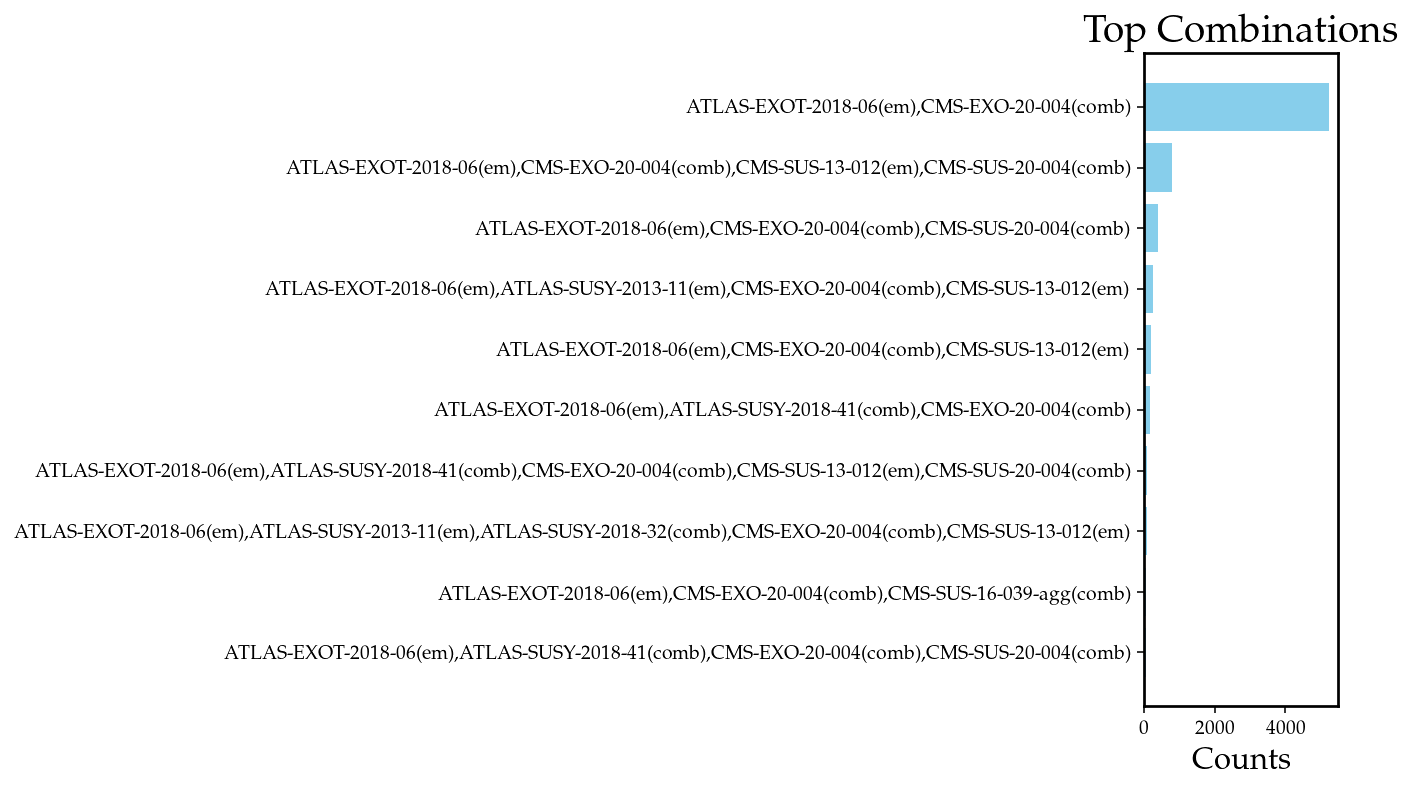

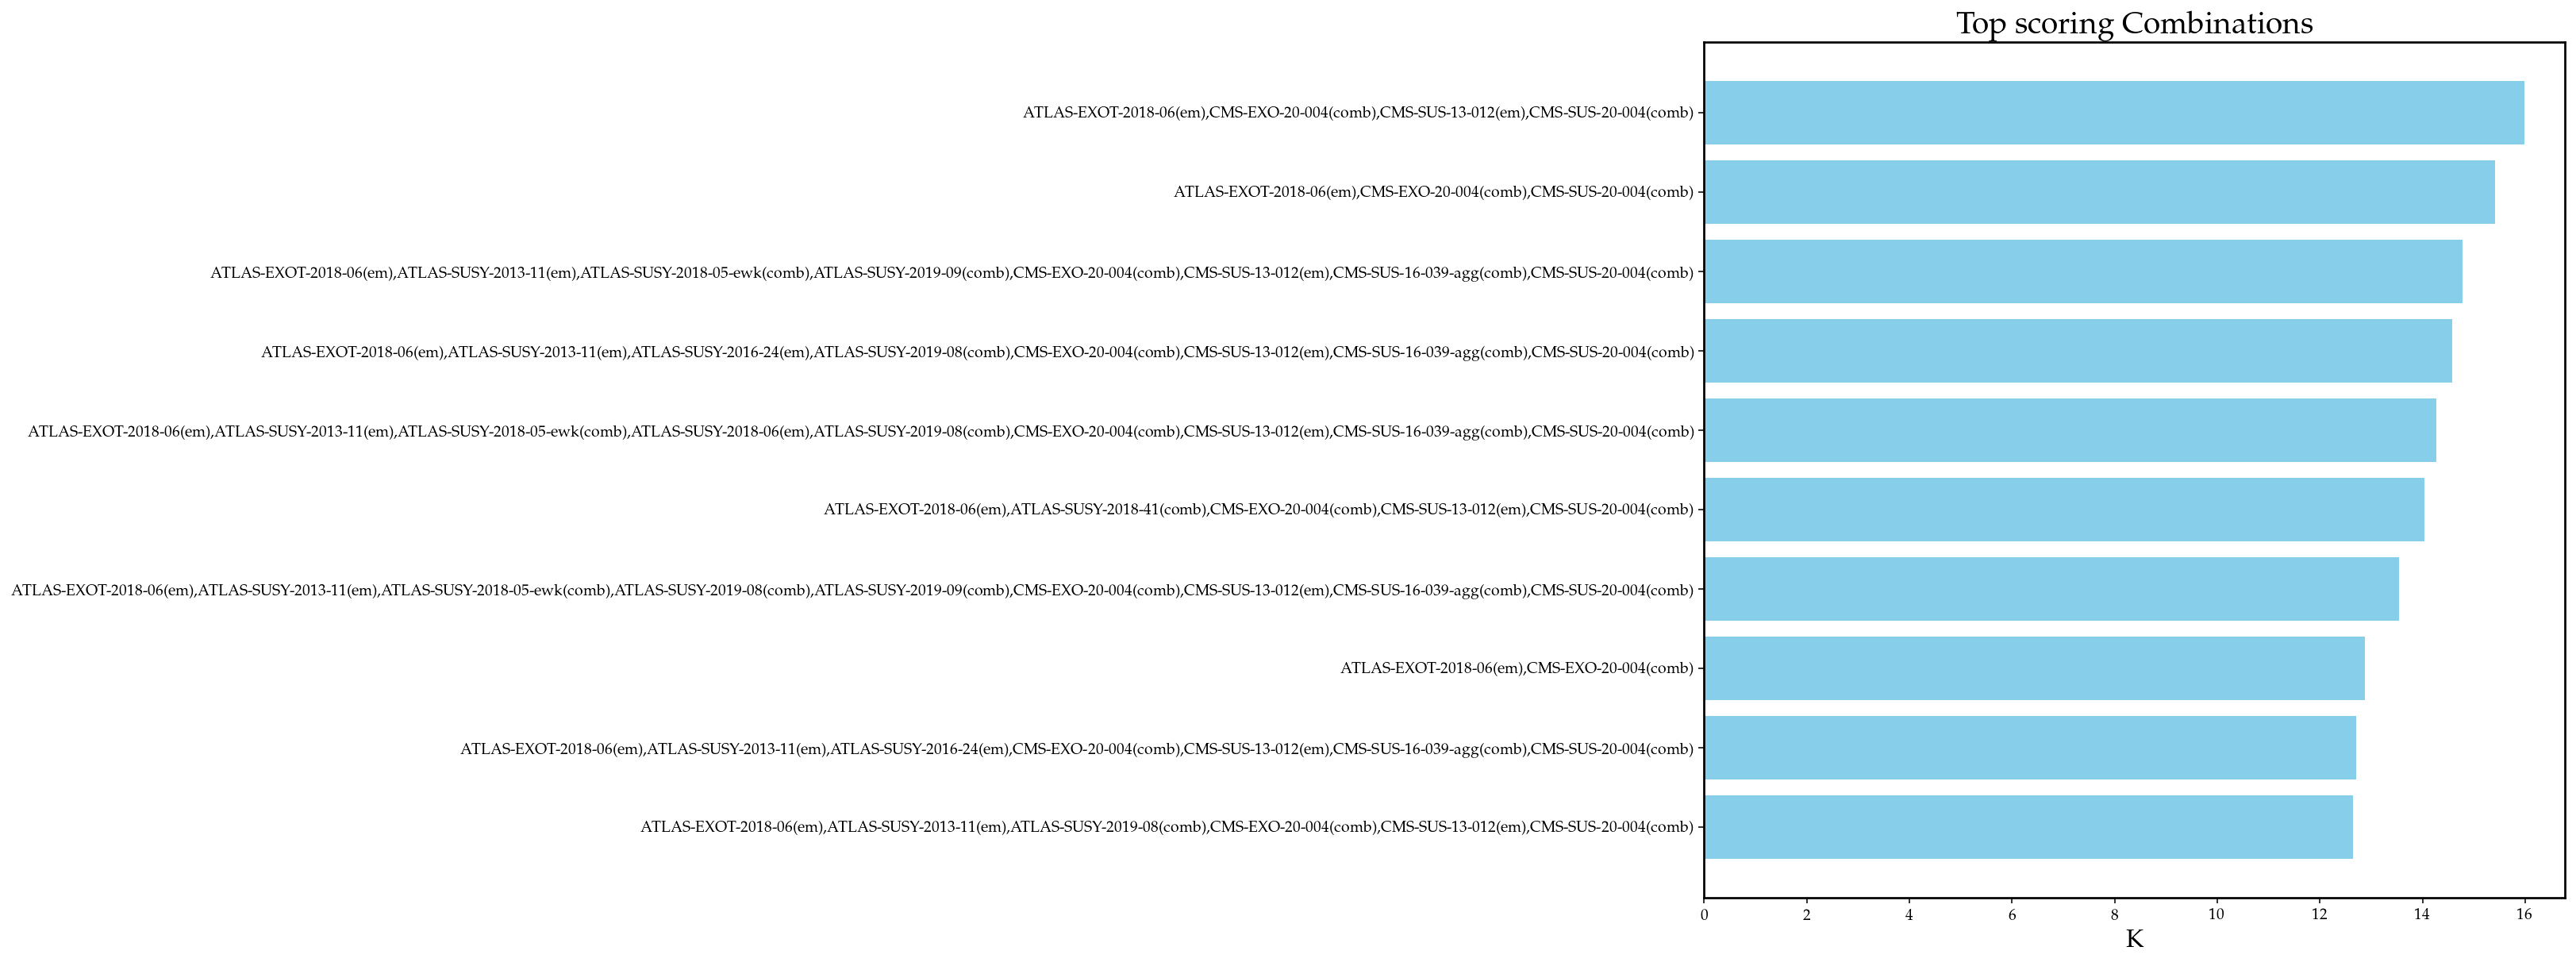

In [24]:
for ind,mp in all_model_posterior.items():
    print("walker ", ind)
    bclist = getBestCombo(mp)
    comb_set = collectBestCombo(bclist)
    stats = statsBestCombo(comb_set, bclist, mp)
    top_stats = dict(sorted(stats.items(), key=lambda item: item[1]['num'], reverse=True)[:10])
    #print(top_stats)
    plotStatsBestCombo(stats)
    #plotExpComb(stats)
    plotTopComb(stats)